# 🔄 Progressive Windows

## Federated Proactive Forest - Implementación Real de Progressive Windows

Este notebook implementa **EXACTAMENTE** la propuesta teórica de PW con 6 fases:

| Fase | Descripción | Implementación |
|------|-------------|---------------|
| **1** | 🌱 Entrenamiento por ventana | Cada cliente entrena W árboles por ronda |
| **2** | 📤 Comunicación | Clientes envían ventana al servidor |
| **3** | 🔄 Round Robin | Agregación secuencial con score dinámico |
| **4** | 🛑 Progressive Global | Criterio de parada (δ ≤ 0.002 × 2 rondas) |
| **5** | 🔄 Actualización | Clientes incorporan globales (sin duplicados) |
| **6** | 🎯 Inferencia híbrida | ŷ = argmax(λ·p_local + (1-λ)·p_global) |

### 🔁 Flujo Incremental Verdadero

```
RONDA 1:
  ├─ Cliente entrena ventana [0:5] → Envía → Round Robin → Verifica convergencia
  └─ Si NO converge → RONDA 2

RONDA 2:
  ├─ Cliente entrena ventana [5:10] → Envía → Round Robin → Verifica convergencia
  └─ Si NO converge → RONDA 3

... (hasta convergencia o max_rounds)
```

### 📋 Contenido
1. Configuración inicial
2. Carga de datos
3. Hiperparámetros
4. **Ejecución PW Incremental** (logs detallados)
5. Resultados y visualizaciones

---

## 1️⃣ Configuración Inicial

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Librerías cargadas")

✅ Librerías cargadas


---

## 2️⃣ Carga del Dataset

In [2]:
df = pd.read_csv('../../../../data/students_dropout.csv', sep=';')
print(f"📊 Dataset: {df.shape[0]} muestras, {df.shape[1]} características")
print(f"\nDistribución Target:\n{df['Target'].value_counts()}")

📊 Dataset: 4424 muestras, 37 características

Distribución Target:
Target
Enrolled    3003
Dropout     1421
Name: count, dtype: int64


In [3]:
target_column = 'Target'
feature_columns = [col for col in df.columns if col != target_column]

X = df[feature_columns].values.astype(np.float64)
y = df[target_column].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = list(le.classes_)

print(f"\n✅ Features: {X.shape} | Clases: {class_names}")


✅ Features: (4424, 36) | Clases: ['Dropout', 'Enrolled']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n📈 Train: {X_train_scaled.shape[0]} | Test: {X_test_scaled.shape[0]}")


📈 Train: 3539 | Test: 885


---

## 2.4️⃣ Feature Selection con Scikit-learn

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

# Use RandomForest to determine feature importances
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train_scaled, y_train)

# Select features based on importance
selector = SelectFromModel(rf_selector, prefit=True, threshold='median')  # Select features above median importance
selector.fit(X_train_scaled, y_train)
X_train_rf = selector.transform(X_train_scaled)
X_test_rf = selector.transform(X_test_scaled)

# Get selected feature names
selected_mask_rf = selector.get_support()
selected_features_rf = [feature_columns[i] for i in range(len(feature_columns)) if selected_mask_rf[i]]

print(f"📊 Random Forest Importance - Top features:")
print(f"   Features seleccionadas: {len(selected_features_rf)}/{len(feature_columns)}")
print(f"   \nFeatures seleccionadas:")
for i, feat in enumerate(selected_features_rf, 1):
    print(f"      {i:2d}. {feat}")

📊 Random Forest Importance - Top features:
   Features seleccionadas: 18/36
   
Features seleccionadas:
       1. Application mode
       2. Course
       3. Previous qualification (grade)
       4. Mother's occupation
       5. Father's occupation
       6. Admission grade
       7. Tuition fees up to date
       8. Age at enrollment
       9. Curricular units 1st sem (enrolled)
      10. Curricular units 1st sem (evaluations)
      11. Curricular units 1st sem (approved)
      12. Curricular units 1st sem (grade)
      13. Curricular units 2nd sem (enrolled)
      14. Curricular units 2nd sem (evaluations)
      15. Curricular units 2nd sem (approved)
      16. Curricular units 2nd sem (grade)
      17. Unemployment rate
      18. GDP


In [6]:
# =============================================================================
# FEATURE SELECTION COMPLETADA
# =============================================================================

print(f"📊 Random Forest Feature Importance")
print(f"   Features seleccionadas: {len(selected_features_rf)}/{len(feature_columns)}")
print(f"   Reducción: {(1 - len(selected_features_rf)/len(feature_columns))*100:.1f}%")
print(f"\n📋 Features seleccionadas:")
for i, feat in enumerate(selected_features_rf, 1):
    print(f"   {i:2d}. {feat}")
print(f"\n✅ Features NO seleccionadas:")
rejected_features = [feature_columns[i] for i in range(len(feature_columns)) if i not in [feature_columns.index(f) for f in selected_features_rf]]
for i, feat in enumerate(rejected_features, 1):
    print(f"   {i:2d}. {feat}")

📊 Random Forest Feature Importance
   Features seleccionadas: 18/36
   Reducción: 50.0%

📋 Features seleccionadas:
    1. Application mode
    2. Course
    3. Previous qualification (grade)
    4. Mother's occupation
    5. Father's occupation
    6. Admission grade
    7. Tuition fees up to date
    8. Age at enrollment
    9. Curricular units 1st sem (enrolled)
   10. Curricular units 1st sem (evaluations)
   11. Curricular units 1st sem (approved)
   12. Curricular units 1st sem (grade)
   13. Curricular units 2nd sem (enrolled)
   14. Curricular units 2nd sem (evaluations)
   15. Curricular units 2nd sem (approved)
   16. Curricular units 2nd sem (grade)
   17. Unemployment rate
   18. GDP

✅ Features NO seleccionadas:
    1. Marital status
    2. Application order
    3. Daytime/evening attendance
    4. Previous qualification
    5. Nacionality
    6. Mother's qualification
    7. Father's qualification
    8. Displaced
    9. Educational special needs
   10. Debtor
   11. Gende

In [7]:
# =============================================================================
# FEATURES FINALES (Random Forest + SelectFromModel)
# =============================================================================

# Final feature set
X_train_final = X_train_rf
X_test_final = X_test_rf
selected_features_final = selected_features_rf

print(f"\n✅ FEATURE SELECTION COMPLETADA")
print(f"   Método: Random Forest + SelectFromModel")
print(f"   Threshold: median")
print(f"   Features finales: {X_train_final.shape[1]}/{len(feature_columns)}")
print(f"   Reducción: {(1 - X_train_final.shape[1]/len(feature_columns))*100:.1f}%")
print(f"\n📋 Features utilizadas:")
for i, feat in enumerate(selected_features_final, 1):
    print(f"   {i:2d}. {feat}")


✅ FEATURE SELECTION COMPLETADA
   Método: Random Forest + SelectFromModel
   Threshold: median
   Features finales: 18/36
   Reducción: 50.0%

📋 Features utilizadas:
    1. Application mode
    2. Course
    3. Previous qualification (grade)
    4. Mother's occupation
    5. Father's occupation
    6. Admission grade
    7. Tuition fees up to date
    8. Age at enrollment
    9. Curricular units 1st sem (enrolled)
   10. Curricular units 1st sem (evaluations)
   11. Curricular units 1st sem (approved)
   12. Curricular units 1st sem (grade)
   13. Curricular units 2nd sem (enrolled)
   14. Curricular units 2nd sem (evaluations)
   15. Curricular units 2nd sem (approved)
   16. Curricular units 2nd sem (grade)
   17. Unemployment rate
   18. GDP


---

## 3️⃣ Hiperparámetros PW

In [8]:
import sys
sys.path.append('../../../../')

from src.application.orchestrators import ProgressiveWindowsOrchestrator
from src.domain.dataset.base_adapter import DatasetSplit

print("✅ PW Incremental importado")

✅ PW Incremental importado


In [9]:
# =============================================================================
# HIPERPARÁMETROS PW INCREMENTAL
# =============================================================================

config = {
    'n_clients': 5,                  # k: Número de clientes
    'aggregation': {
        'window_size': 5,             # W: Árboles por ventana
        'max_rounds': 20,             # R_MAX: Máximo de rondas
        'f1_weight': 0.5,             # α: Balance F1 vs Diversidad
        'convergence_threshold': 0.002  # δ: Umbral de convergencia
    },
    'prediction': {
        'local_weight': 0.5,          # λ: Peso local
        'global_weight': 0.5          # (1-λ): Peso global
    },
    'alpha_pf': 0.1,                  # Parámetro Proactive Forest
    'verbose': True                   # Logs detallados
}

print("=" * 80)
print("⚙️ CONFIGURACIÓN PW INCREMENTAL")
print("=" * 80)
print(f"\n📋 Parámetros:")
print(f"   • Clientes (k): {config['n_clients']}")
print(f"   • Ventana (W): {config['aggregation']['window_size']} árboles")
print(f"   • Máx rondas (R_MAX): {config['aggregation']['max_rounds']}")
print(f"   • F1 Weight (α): {config['aggregation']['f1_weight']}")
print(f"   • PCD Weight (β): {1.0 - config['aggregation']['f1_weight']:.2f}")
print(f"   • Lambda (λ): {config['prediction']['local_weight']}")
print(f"   • Convergencia (δ): {config['aggregation']['convergence_threshold']}")
print(f"\n📊 Fórmula Score: Score(T) = α·F1(T) + β·Diversidad(T|G)")
print(f"📊 Fórmula Inferencia: ŷ = argmax(λ·p_local + (1-λ)·p_global)")
print("=" * 80)

⚙️ CONFIGURACIÓN PW INCREMENTAL

📋 Parámetros:
   • Clientes (k): 5
   • Ventana (W): 5 árboles
   • Máx rondas (R_MAX): 20
   • Alpha (α): 0.5
   • Lambda (λ): 0.5
   • Convergencia (δ): 0.002

📊 Fórmula Score: Score(T) = α·F1(T) + (1-α)·Diversidad(T|G)
📊 Fórmula Inferencia: ŷ = argmax(λ·p_local + (1-λ)·p_global)


---

## 4️⃣ EJECUCIÓN PW INCREMENTAL VERDADERO

**IMPORTANTE**: Verás logs detallados de cada ronda:

```
🔁 RONDA X/Y
  🌱 FASE 1: Entrenamiento de ventanas
  🔄 FASE 2-3: Round Robin con ranking
     🎲 Permutación aleatoria
     👤 TURNO 1: client_X
        📊 Ranking: F1, Diversidad, Score
        ✅ SELECCIONADO: T0
  🛑 FASE 4: Criterio de parada
```

**Ejecutar esta celda**

---

## 3.4️⃣ Creación del DatasetSplit y Orquestador

In [10]:
# Crear DatasetSplit con las features seleccionadas
dataset_split = DatasetSplit(
    X_train=X_train_final, 
    X_test=X_test_final,
    y_train=y_train, 
    y_test=y_test,
    feature_names=selected_features_final,
    class_names=class_names,
    dataset_name='Students Dropout (Feature Selected)'
)

print(f"✅ DatasetSplit creado")
print(f"   Train samples: {dataset_split.X_train.shape[0]}")
print(f"   Test samples: {dataset_split.X_test.shape[0]}")
print(f"   Features: {dataset_split.X_train.shape[1]}")
print(f"   Classes: {dataset_split.class_names}")

✅ DatasetSplit creado
   Train samples: 3539
   Test samples: 885
   Features: 18
   Classes: ['Dropout', 'Enrolled']


In [11]:
# Crear orquestador PW incremental verdadero
orchestrator = ProgressiveWindowsOrchestrator(
    config=config,
    dataset_split=dataset_split,
    verbose=True
)

print(f"\n✅ PW Incremental configurado")
print(f"   Orchestrator: {orchestrator.__class__.__name__}")
print(f"   Strategy: {orchestrator.strategy.strategy_id}")
print(f"   Window size: {orchestrator.window_size}")
print(f"   Max rounds: {orchestrator.max_rounds}")
print(f"   Alpha: {orchestrator.alpha}")
print(f"   Lambda: {orchestrator.local_weight}")


✅ PW Incremental configurado
   Orchestrator: ProgressiveWindowsOrchestrator
   Strategy: PW
   Window size: 5
   Max rounds: 20
   Alpha: 0.5
   Lambda: 0.5


In [12]:
# Ejecutar PW incremental verdadero
print("\n" + "=" * 100)
print("🚀 INICIANDO PW INCREMENTAL VERDADERO")
print("=" * 100)

results = orchestrator.run_federated_round()

print("\n✅ PW COMPLETADO")


🚀 INICIANDO PW INCREMENTAL VERDADERO

🚀 INICIANDO PROGRESSIVE WINDOWS INCREMENTAL VERDADERO

📋 Configuración:
   • Clientes: 5
   • Ventana (W): 5 árboles
   • Máx rondas: 20
   • Alpha: 0.5
   • Lambda: 0.5


🔁 RONDA 1/20
📊 Bosque global actual: 0 árboles
📈 Accuracy actual: N/A (bosque vacío)

────────────────────────────────────────────────────────────────────────────────────────────────────
🌱 FASE 1: ENTRENAMIENTO DE VENTANAS LOCALES
────────────────────────────────────────────────────────────────────────────────────────────────────
   client_0: 5 árboles entrenados (Accuracy=0.8429)
   client_1: 5 árboles entrenados (Accuracy=0.8350)
   client_2: 5 árboles entrenados (Accuracy=0.8452)
   client_3: 5 árboles entrenados (Accuracy=0.8610)
   client_4: 5 árboles entrenados (Accuracy=0.8554)

────────────────────────────────────────────────────────────────────────────────────────────────────
🔄 FASE 2-3: AGREGACIÓN ROUND ROBIN DINÁMICA
───────────────────────────────────────────────────

---

## 5️⃣ Resultados

In [13]:
print("=" * 100)
print("📊 RESULTADOS GLOBALES")
print("=" * 100)

print(f"\n🌲 BOSQUE GLOBAL:")
print(f"   • Árboles: {results.n_trees_global}")
print(f"   • Accuracy: {results.global_accuracy:.6f} ({results.global_accuracy*100:.2f}%)")
print(f"   • Macro-F1: {results.global_macro_f1:.6f}")

print(f"\n🔁 RONDAS:")
print(f"   • Completadas: {results.num_rounds}")
if results.convergence_round and results.convergence_round < results.num_rounds:
    print(f"   • Convergencia temprana: Ronda {results.convergence_round}")
    print(f"   • Rondas ahorradas: {config['aggregation']['max_rounds'] - results.convergence_round}")
else:
    print(f"   • Máximo rondas alcanzado")

print(f"\n📈 ÁRBOLES POR CLIENTE:")
for cid in sorted(results.selected_ids.keys()):
    n = len(results.selected_ids[cid])
    print(f"   • {cid}: {n} árboles")

📊 RESULTADOS GLOBALES

🌲 BOSQUE GLOBAL:
   • Árboles: 75
   • Accuracy: 0.862147 (86.21%)
   • Macro-F1: 0.832370

🔁 RONDAS:
   • Completadas: 15
   • Máximo rondas alcanzado

📈 ÁRBOLES POR CLIENTE:
   • client_0: 15 árboles
   • client_1: 15 árboles
   • client_2: 15 árboles
   • client_3: 15 árboles
   • client_4: 15 árboles


In [14]:
# Métricas por cliente
print("\n" + "=" * 100)
print("📈 MÉTRICAS POR CLIENTE (Inferencia Híbrida)")
print("=" * 100)

print(f"\n{'Cliente':<12} | {'Accuracy':<12} | {'Macro-F1':<12} | {'Tamaño':<8}")
print("-" * 100)

for cid in sorted(results.client_ids):
    acc = results.client_accuracies.get(cid, 0)
    f1 = results.client_f1_scores.get(cid, 0)
    size = results.client_hybrid_forest_sizes.get(cid, 0)
    print(f"{cid:<12} | {acc:<12.6f} | {f1:<12.6f} | {size:<8}")

print("-" * 100)
avg_acc = np.mean([results.client_accuracies[cid] for cid in results.client_ids])
avg_f1 = np.mean([results.client_f1_scores[cid] for cid in results.client_ids])
print(f"{'PROMEDIO':<12} | {avg_acc:<12.6f} | {avg_f1:<12.6f} | {'':<8}")


📈 MÉTRICAS POR CLIENTE (Inferencia Híbrida)

Cliente      | Accuracy     | Macro-F1     | Tamaño  
----------------------------------------------------------------------------------------------------
client_0     | 0.859887     | 0.831547     | 65      
client_1     | 0.862147     | 0.831187     | 65      
client_2     | 0.863277     | 0.832769     | 65      
client_3     | 0.864407     | 0.836247     | 65      
client_4     | 0.863277     | 0.833551     | 65      
----------------------------------------------------------------------------------------------------
PROMEDIO     | 0.862599     | 0.833060     |         


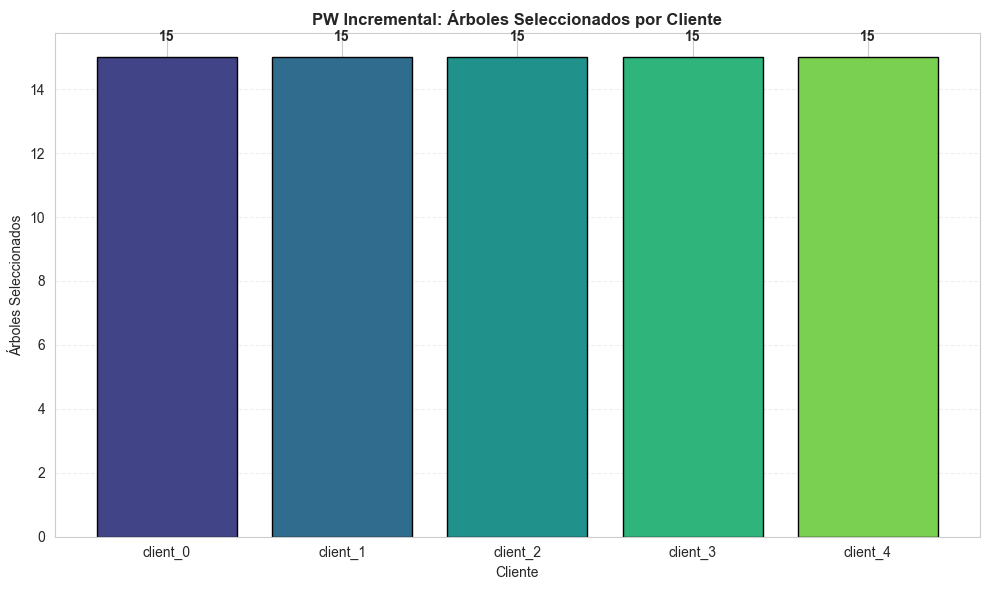

In [15]:
# Visualización: Árboles seleccionados por cliente
fig, ax = plt.subplots(figsize=(10, 6))

client_ids = sorted(results.selected_ids.keys())
trees_selected = [len(results.selected_ids[cid]) for cid in client_ids]

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(client_ids)))
bars = ax.bar(client_ids, trees_selected, color=colors, edgecolor='black')

ax.set_xlabel('Cliente')
ax.set_ylabel('Árboles Seleccionados')
ax.set_title('PW Incremental: Árboles Seleccionados por Cliente', fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

for bar, val in zip(bars, trees_selected):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

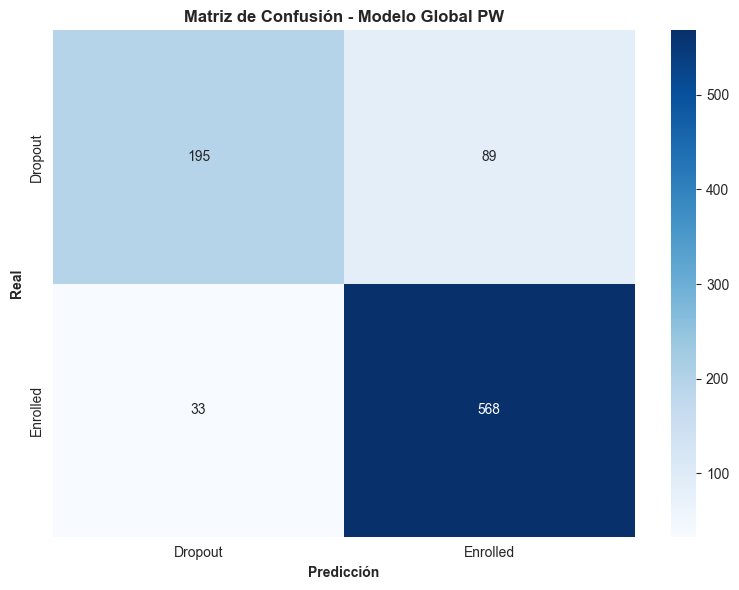

In [16]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(results.y_test, results.global_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)

ax.set_xlabel('Predicción', fontweight='bold')
ax.set_ylabel('Real', fontweight='bold')
ax.set_title('Matriz de Confusión - Modelo Global PW', fontweight='bold')

plt.tight_layout()
plt.show()

In [17]:
# Reporte de clasificación
print("=" * 100)
print("📋 REPORTE DE CLASIFICACIÓN")
print("=" * 100)
print(classification_report(results.y_test, results.global_predictions, target_names=class_names))

📋 REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

     Dropout       0.86      0.69      0.76       284
    Enrolled       0.86      0.95      0.90       601

    accuracy                           0.86       885
   macro avg       0.86      0.82      0.83       885
weighted avg       0.86      0.86      0.86       885



In [18]:
# Resumen final
print("\n" + "=" * 100)
print("📊 RESUMEN FINAL - PW INCREMENTAL")
print("=" * 100)

print(f"\n🔧 HIPERPARÁMETROS:")
print(f"   • Clientes: {config['n_clients']}")
print(f"   • Ventana (W): {config['aggregation']['window_size']}")
print(f"   • Máx rondas: {config['aggregation']['max_rounds']}")
print(f"   • Alpha: {config['aggregation']['alpha']}")
print(f"   • Lambda: {config['prediction']['local_weight']}")

print(f"\n🌲 BOSQUE GLOBAL:")
print(f"   • Árboles: {results.n_trees_global}")
print(f"   • Accuracy: {results.global_accuracy:.4f} ({results.global_accuracy*100:.2f}%)")
print(f"   • Macro-F1: {results.global_macro_f1:.4f}")

print(f"\n🔁 RONDAS:")
print(f"   • Completadas: {results.num_rounds}")
if results.convergence_round and results.convergence_round < results.num_rounds:
    print(f"   • Convergencia: Ronda {results.convergence_round} (temprana)")
else:
    print(f"   • Sin convergencia temprana")

print("\n" + "=" * 100)
print("✅ PW INCREMENTAL COMPLETADO EXITOSAMENTE")
print("=" * 100)


📊 RESUMEN FINAL - PW INCREMENTAL

🔧 HIPERPARÁMETROS:
   • Clientes: 5
   • Ventana (W): 5
   • Máx rondas: 20
   • Alpha: 0.5
   • Lambda: 0.5

🌲 BOSQUE GLOBAL:
   • Árboles: 75
   • Accuracy: 0.8621 (86.21%)
   • Macro-F1: 0.8324

🔁 RONDAS:
   • Completadas: 15
   • Sin convergencia temprana

✅ PW INCREMENTAL COMPLETADO EXITOSAMENTE
